# Regression Project Explanation

#### First importing packages:

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import linear_model

#### Reading CSV file:

In [2]:
df = pd.read_csv("house-price.csv")
df

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
...,...,...,...,...,...,...,...,...
3474,86,2,True,True,True,Southern Janatabad,3.500000e+09,116666.67
3475,83,2,True,True,True,Niavaran,6.800000e+09,226666.67
3476,75,2,False,False,False,Parand,3.650000e+08,12166.67
3477,105,2,True,True,True,Dorous,5.600000e+09,186666.67


#### We review which datasets has **empty** Address:

In [ ]:
df[df['Address'].isnull()]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
43,60,2,True,True,True,NaN,2.650000e+09,88333.33
662,85,2,True,True,True,NaN,1.955000e+09,65166.67
706,117,2,True,True,True,NaN,6.500000e+09,216666.67
1108,77,2,True,True,False,NaN,2.020000e+09,67333.33
1109,71,1,True,True,True,NaN,2.300000e+09,76666.67
1577,100,2,True,True,True,NaN,3.100000e+09,103333.33
1796,70,2,True,True,True,NaN,4.830000e+09,161000.00
2071,94,2,True,True,True,NaN,3.000000e+09,100000.00
2072,99,2,True,True,True,NaN,4.150000e+09,138333.33
2127,63,1,True,True,False,NaN,7.300000e+08,24333.33


In [6]:
print(df.isnull().sum())

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64


#### Drop this rows (Address = Null):

In [7]:
df = df.dropna(subset=['Address'])

In [8]:
print(df.isnull().sum())

Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64


#### Let's manage the unreal Areas:

In [10]:
df['Area'].describe()

count     3456
unique     243
top         75
freq       111
Name: Area, dtype: object

<ul style="font-size: 0.85em;">
  <li>Count means How many un-null datas we have.</li>
  <li>unique means How many non-repetitive datas we have.</li>
  <li>top means which data repeted <b>most</b>.</li>
  <li>freq means how many times a value repeats in a dataset.</li>
</ul>

$$
IQR = Q_3 - Q_1
$$

$$
\text{Upper Bound} = Q_3 + 1.5 \times IQR
$$

$$
\text{Lower Bound} = Q_1 - 1.5 \times IQR
$$

In [16]:
df['Area'] = pd.to_numeric(df['Area'])
Q1 = df['Area'].quantile(0.25)
Q3 = df['Area'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(upper_bound)

196.5


In [ ]:
before = len(df)
df = df[df['Area'] <= upper_bound]
after = len(df)
print(f"Count before removing: {before}")
print(f"Count after removing: {after}")
print(f"Removed: {before - after} Rowes ({(before-after)/before*100:.2f}%)")
# Removing
df = df[(df['Area'] < upper_bound) & (df['Area'] > lower_bound) ]

#### Changing True & False to 1 & 0:

In [26]:
df['Parking'] = df['Parking'].astype(int)
df['Warehouse'] = df['Warehouse'].astype(int)
df['Elevator'] = df['Elevator'].astype(int)

In [27]:
df

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63.0,1,1,1,1,Shahran,1.850000e+09,61666.67
1,60.0,1,1,1,1,Shahran,1.850000e+09,61666.67
2,79.0,2,1,1,1,Pardis,5.500000e+08,18333.33
3,95.0,2,1,1,1,Shahrake Qods,9.025000e+08,30083.33
4,123.0,2,1,1,1,Shahrake Gharb,7.000000e+09,233333.33
...,...,...,...,...,...,...,...,...
3474,86.0,2,1,1,1,Southern Janatabad,3.500000e+09,116666.67
3475,83.0,2,1,1,1,Niavaran,6.800000e+09,226666.67
3476,75.0,2,0,0,0,Parand,3.650000e+08,12166.67
3477,105.0,2,1,1,1,Dorous,5.600000e+09,186666.67


In [28]:
print(df['Address'].nunique())

187


In [ ]:
df = df.drop(columns=['Address'])

In [31]:
print(df.columns)

Index(['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price',
       'Price(USD)'],
      dtype='str')


#### Feature selection (X) and target selection (y)

In [49]:
cdf = df[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price']]

In [50]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

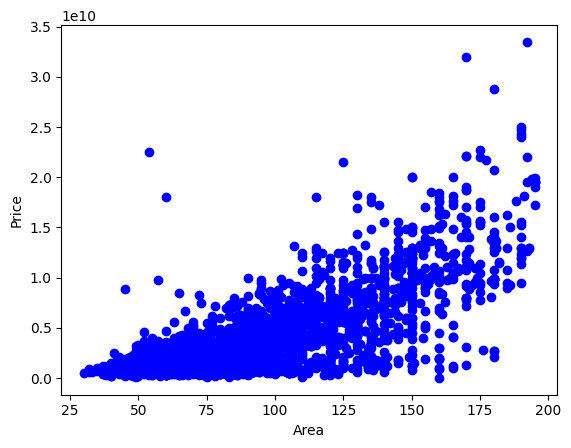

In [51]:
plt.scatter(cdf.Area, cdf.Price,  color='blue')
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [53]:
regr = linear_model.LinearRegression()

x_train = np.asanyarray(train[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator']])
y_train = np.asanyarray(train[['Price']])

regr.fit(x_train, y_train)
print ('Coefficients: ', regr.coef_)

Coefficients:  [[ 8.93789881e+07 -6.63953669e+08  5.13618772e+08  4.11639296e+08
   2.19600925e+08]]


#### Prediction:

In [54]:
x_test = np.asanyarray(test[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator']])
y_test = np.asanyarray(test[['Price']])
y_hat = regr.predict(x_test)


print("Residual sum of squares: %.2f"
      % np.mean((y_hat - y_test) ** 2))

# Explained variance score: 1 is perfect prediction
print('Variance score: %.2f' % regr.score(x_test, y_test))

Residual sum of squares: 8192806262455518208.00
Variance score: 0.52
